# Mapping the supply & demand of public EV charging station distribution across Israel

### Brief intro on charging stations and the Israeli EV market

Electric Vehicles (EVs) play a vital role in the global fight against climate change - transitioning a country's fleet to electric power can significantly slash air pollution and carbon emissions.

A study conducted for the Ministry of Energy mapped the positions of the Israeli consumer regarding the obstacles of electric vehicle usage on the one hand, and the motivations for adoption on the other. Given that there is a supply of vehicles on the market, the study shows that the main barrier, as perceived by consumers, is the lack of public charging stations for electric vehicles in the country.

To overcome the above obstacles, many countries, including Israel, are encouraging the construction of a network of **public** charging stations. These charging stations are intended to allow people who have no **private** charging station to charge their electric vehicle, and thus increase the daily autonomy of the vehicle also for those who have a private charging station. This network consists of fast charging stations that provide direct current (DC) and slow charging stations that provide alternating current (AC).

In general - 'slow' charging stations (AC) are the standard. They're cheaper to build and use - but they require you to charge your car for 6~12 hours for a full charge. They're perfect for overnight charging if you have your own parking spot at home, or for parking during work hours while you're working at the office.
Fast chargers (DC) can top up your battery by 20~60 minutes! But.. fast chargers shorten the EV's battery lifespan. They're also really expensive to build and use.

Most EV owners will ideally want their own parking space with a **private** AC charging station built on it. But what if I don't have my own parking space and I rely on public or curbside parking? That's when the need for a network of **public** charging stations comes in. 

Main question - **Where do we need more public charging stations built?**

In this project I'd like to visualize and quantify in which geographical areas are Israeli citizens lacking public EV charging stations, which in turn might also discourage non-EV owners from switching over to EVs.

### Data sources used in this project

- OpenStreetMap (filtered via Overpass Turbo (https://overpass-turbo.eu/)) databases, for open-source information on Points of Interest (POIs) and parking lot areas.
- Official government data from data.gov, specifically data on existing charging stations from the Ministry of Transport (https://data.gov.il/he/datasets/ministry_of_transport/agg_charge_stations) and the latest census data from the Israel Central Bureau of Statistics (https://data.gov.il/he/datasets/lamas/2022)
- The open-source "Open Bus Stride API" (https://open-bus-stride-api.hasadna.org.il/docs) to get data on Public Transport accesibility in Israel.

### Part 1: Initial extraction and exploration

I'll start by using Overpass Turbo queries to get all POIs on OpenstreetMap that are marked as:

<details>
<summary> 'parking', 'parking_space' or 'parking_entrance' (here I included the actual polygons) </summary>

```
{{geocodeArea:Israel}}->.searchArea;

(
  // 1. General parking facilities (surface, multi-storey, underground)
  nwr["amenity"="parking"](area.searchArea);
  
  // 2. Individual parking spaces (useful for density analysis)
  nwr["amenity"="parking_space"](area.searchArea);
  
  // 3. Entrances/Exits to underground or multi-storey parking
  node["amenity"="parking_entrance"](area.searchArea);
);

// Output the results with geometries
out body;
>;
out skel qt;
```

<details>
<summary>'shop', 'restaurant', 'cafe', 'fast_food', 'bank', 'pharmacy', 'clinic', 'hospital', 'office' or 'park' (here I only pulled the centroids, since I'm planning on clustering them) </summary>

```
[out:json][timeout:300];

{{geocodeArea:Israel}}->.searchArea;

(
  // 2. Commercial: All shops (malls, supermarkets, boutiques)
  nwr["shop"](area.searchArea);
  
  // 3. Amenities: Restaurants, cafes, banks, pharmacies, clinics
  nwr["amenity"~"restaurant|cafe|fast_food|bank|pharmacy|clinic|hospital"](area.searchArea);
  
  // 4. Offices: Corporate buildings, co-working spaces
  nwr["office"](area.searchArea);
  
  // 5. Leisure: Parks and community centers (good for mid-stay charging)
  nwr["leisure"~"park|community_centre"](area.searchArea);
);

/* Used 'out center' so I only get the centroids of my POIs
*/
out center;
```

In [17]:
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import matplotlib.pyplot as plt

file_path = "POIs_center.geojson"
poi_df = gpd.read_file(file_path)

Skipping field service_times: unsupported OGR type: 10


In [18]:
poi_df.info()
print('\n', poi_df.head(), '\n')

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 33774 entries, 0 to 33773
Columns: 631 entries, id to geometry
dtypes: datetime64[ms](7), float64(1), geometry(1), str(622)
memory usage: 162.6 MB

                  id               @id FIXME Rate access addr:city  \
0     way/239196738     way/239196738   NaN  NaN    NaN       NaN   
1     way/639130875     way/639130875   NaN  NaN    NaN       NaN   
2  relation/2674121  relation/2674121   NaN  NaN    NaN       NaN   
3  relation/2720477  relation/2720477   NaN  NaN    NaN       NaN   
4  relation/3231325  relation/3231325   NaN  NaN    NaN       NaN   

  addr:city:ar addr:city:arc addr:city:en addr:city:he  ... wikidata  \
0          NaN           NaN          NaN          NaN  ...      NaN   
1          NaN           NaN          NaN          NaN  ...      NaN   
2          NaN           NaN          NaN          NaN  ...      NaN   
3          NaN           NaN          NaN          NaN  ...      NaN   
4          NaN    

Right off the bat, we can see a ton of useless columns. Each point on Openpass can have up to 631 possible 'tags', but we only queried for 4 specific tags (amenity, shop, office, leisure) so we can safely remove all of the columns related to tags we did not ask for.

['amenity', 'shop', 'office', 'leisure', 'geometry'] 

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 33774 entries, 0 to 33773
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   amenity   6396 non-null   str     
 1   shop      9739 non-null   str     
 2   office    859 non-null    str     
 3   leisure   16843 non-null  str     
 4   geometry  33774 non-null  geometry
dtypes: geometry(1), str(4)
memory usage: 1.3 MB

   amenity         shop office leisure  \
0     NaN  convenience    NaN     NaN   
1     NaN          NaN    yes     NaN   
2     NaN          NaN    NaN    park   
3     NaN          NaN    NaN    park   
4     NaN          NaN    NaN    park   

                                            geometry  
0  LINESTRING (34.63127 31.76679, 34.63107 31.766...  
1  LINESTRING (34.77307 31.60403, 34.77312 31.604...  
2                           POINT (34.63878 31.7865)  
3                          POIN

<Axes: >

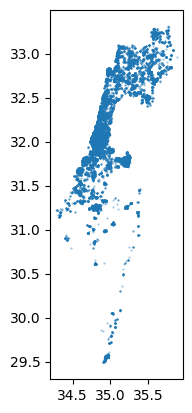

In [ ]:
expected_cols = ['amenity', 'shop', 'office', 'leisure', 'geometry']

# check if these columns exists first
existing_cols = [col for col in expected_cols if col in poi_df.columns]
print(existing_cols, '\n') # cool! they're all here and have the expected names

poi_df = poi_df[existing_cols]
poi_df.info()
print('\n', poi_df.head())
poi_df.plot(markersize=0.2, alpha=0.5) 
# the map looks nice! looks like the OSM data is extensive across the country

In [42]:
# I noticed the geometry also includes non-centroids!
print(poi_df.geometry.geom_type.value_counts())

Point         33772
LineString        2
Name: count, dtype: int64
